# 假设检验与效应大小

## Goal
对同一份配对数据，把效应、不确定性和错误控制区分清楚。正文和18题详解分别见lecture.pdf与answers.pdf，独立实验路线见lab.pdf。

本次实际基线：平均差2，t双侧p约.02546，95%区间[.32796,3.67204]；完整符号翻转有12/256个尾部标签。20项独立真零比较的未校正家族误拒比例.6441，Bonferroni后.0504；共享前缀查看的任一过线比例.1742。这些模拟比例是10000批的有限结果，不是普遍定理。

## Setup
在本单元目录启动Notebook，Restart Kernel后Run All。每次重新读默认CSV与配置并重算，不读取历史report.json，也不依赖作者的构建脚本。图用内存PNG保留，不需要网络、API、GPU或图形桌面。

### Key Assumptions
差值方向B−A，独立配对单位。z模型使用外部已知σ=2；配对t模型使用独立Gaussian差值、σ未知；符号翻转使用各对独立交换或独立零对称，零均值本身不足。模拟是已知σ Gaussian基准。完整枚举的双侧定义为绝对总差尾部。

In [1]:
import sys, math, io
from fractions import Fraction
from itertools import product
import numpy as np
import scipy
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import experiment as e
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.facecolor':'white'})
def show(fig):
    fig.tight_layout(pad=1.4)
    buffer=io.BytesIO()
    fig.savefig(buffer,format='png',dpi=140,bbox_inches='tight')
    plt.close(fig)
    display(Image(data=buffer.getvalue()))
ids,a,b=e.read_pairs(e.ROOT/'data/paired_scores.csv')
spec=e.read_spec(e.ROOT/'data/model_spec.json')
e.require(ids==[f'P{i:02}' for i in range(1,9)], 'This tutorial uses baseline IDs')
e.require(a==[10,12,9,15,13,11,14,8] and b==[13,14,13,16,12,11,16,13], 'Use a new analysis for changed data')
e.require(spec=={'kind':'synthetic_paired_hypothesis_demo','seed':26026,'repetitions':10000,'known_sigma':2.,'alpha':.05,'null_delta':0.,'power_deltas':[0.,.5,1.,2.],'power_sizes':[8,32,128],'family_sizes':[1,5,20],'practical_threshold':1.5},'Use script --spec for changed design')
print({'Python':sys.version.split()[0],'NumPy':np.__version__,'SciPy':scipy.__version__,'Matplotlib':matplotlib.__version__,'RNG':'PCG64'})
print('Synthetic independent paired units:', list(zip(ids,a,b)))

{'Python': '3.12.14', 'NumPy': '2.3.5', 'SciPy': '1.17.0', 'Matplotlib': '3.10.8', 'RNG': 'PCG64'}
Synthetic independent paired units: [('P01', 10.0, 13.0), ('P02', 12.0, 14.0), ('P03', 9.0, 13.0), ('P04', 15.0, 16.0), ('P05', 13.0, 12.0), ('P06', 11.0, 11.0), ('P07', 14.0, 16.0), ('P08', 8.0, 13.0)]


## Steps
### 1. 从配对和Fraction开始
用整数输入的精确有理运算算均值、SSE、方差和协方差；不依赖下面的统计库答案。一次样本的效应估计不是总体参数本身。

D= [3, 2, 4, 1, -1, 0, 2, 5] mean= 2 SSE= 28 s2= 4 covariance= 18/7
Paired mean variance: 0.5 incorrect independent: 1.1428571428571428


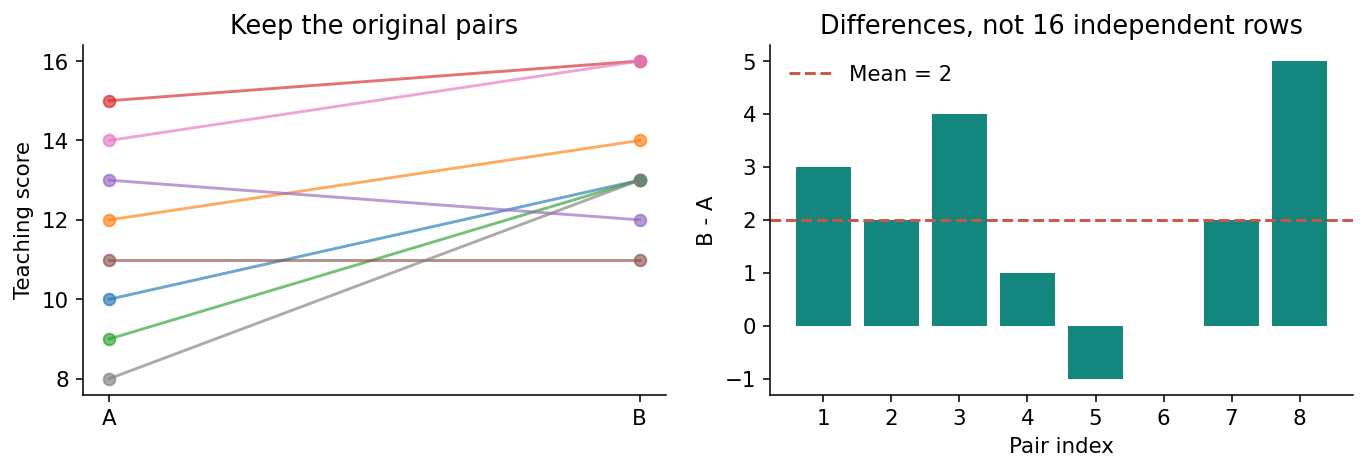

In [2]:
d=[int(y-x) for x,y in zip(a,b)]
n=len(d)
exact_mean=sum(map(Fraction,d))/n
sse=sum((Fraction(v)-exact_mean)**2 for v in d)
mean_a=sum(map(Fraction,a))/n
mean_b=sum(map(Fraction,b))/n
cov=sum((Fraction(x)-mean_a)*(Fraction(y)-mean_b) for x,y in zip(a,b))/(n-1)
e.require(exact_mean==2 and sse==28 and cov==Fraction(18,7), 'Fraction reference mismatch')
paired=e.paired_summary(a,b)
print('D=',d,'mean=',exact_mean,'SSE=',sse,'s2=',sse/(n-1),'covariance=',cov)
print('Paired mean variance:',paired['paired_mean_variance'],'incorrect independent:',paired['incorrect_independent_mean_variance'])
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for x,y in zip(a,b):axes[0].plot([0,1],[x,y],marker='o',alpha=.65)
axes[0].set(xticks=[0,1],xticklabels=['A','B'],ylabel='Teaching score',title='Keep the original pairs')
axes[1].bar(range(1,9),d,color='#13867d');axes[1].axhline(2,color='#ca5646',ls='--',label='Mean = 2')
axes[1].set(xlabel='Pair index',ylabel='B - A',title='Differences, not 16 independent rows');axes[1].legend(frameon=False)
show(fig)

### 2. 相同观察统计量，不同参考分布
外部已知σ恰好等于样本s是设计巧合。SciPy的ttest_rel按第一数组减第二数组，因此这里传b,a。Gaussian样本的Student精确分布定理在本讲接受，不把模拟当证明。

External-sigma z: {'status': 'ok', 'method': 'external_known_sigma_Gaussian_z', 'n': 8, 'mean': 2.0, 'sigma': 2.0, 'null': 0.0, 'alpha': 0.05, 'se': 0.7071067811865475, 'statistic': 2.8284271247461903, 'p_two_sided': 0.0046777349810472576, 'critical': 1.9599639845400545, 'interval': [0.614096175650322, 3.385903824349678], 'reject': True}
Unknown-sigma t: {'status': 'ok', 'method': 'paired_Gaussian_t', 'n': 8, 'mean': 2.0, 'sd': 2.0, 'null': 0.0, 'alpha': 0.05, 'se': 0.7071067811865475, 'df': 7, 'statistic': 2.8284271247461903, 'p_two_sided': 0.02546356168323925, 'critical': 2.3646242515927844, 'interval': [0.3279581567405774, 3.6720418432594224], 'reject': True, 'd_z': 1.0}


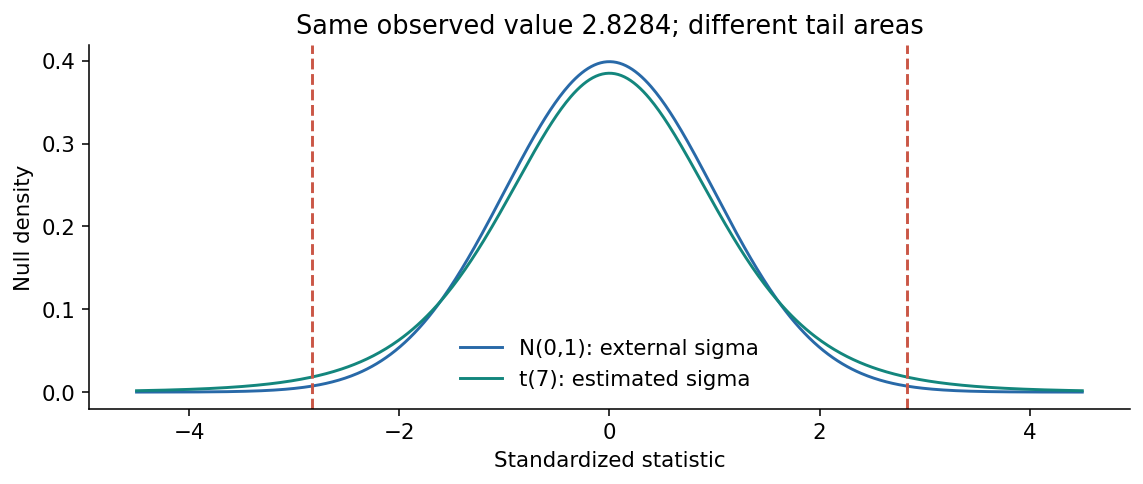

In [3]:
z=e.known_sigma_test(d,2)
t=e.paired_t_test(d)
reference=stats.ttest_rel(b,a,nan_policy='raise')
e.require(math.isclose(t['statistic'],float(reference.statistic),rel_tol=1e-13),'paired sign/order mismatch')
e.require(math.isclose(t['p_two_sided'],float(reference.pvalue),rel_tol=1e-13),'t p mismatch')
print('External-sigma z:',z)
print('Unknown-sigma t:',t)
x=np.linspace(-4.5,4.5,600)
fig,ax=plt.subplots(figsize=(8.5,3.7))
ax.plot(x,stats.norm.pdf(x),label='N(0,1): external sigma',color='#2869a8')
ax.plot(x,stats.t.pdf(x,7),label='t(7): estimated sigma',color='#13867d')
for v in [-abs(t['statistic']),abs(t['statistic'])]:ax.axvline(v,color='#ca5646',ls='--')
ax.set(xlabel='Standardized statistic',ylabel='Null density',title='Same observed value 2.8284; different tail areas')
ax.legend(frameon=False);show(fig)

### 3. 效应区间与实用阈值
原始效应2分，配对d_z=1。t区间包含1.5，不能从排除0跳到“已经超过1.5”。图中两种区间使用不同模型信息，不按较短者筛选。

Raw effect: 2.0 teaching points; d_z: 1.0
Practical threshold: 1.5 inside t CI: True


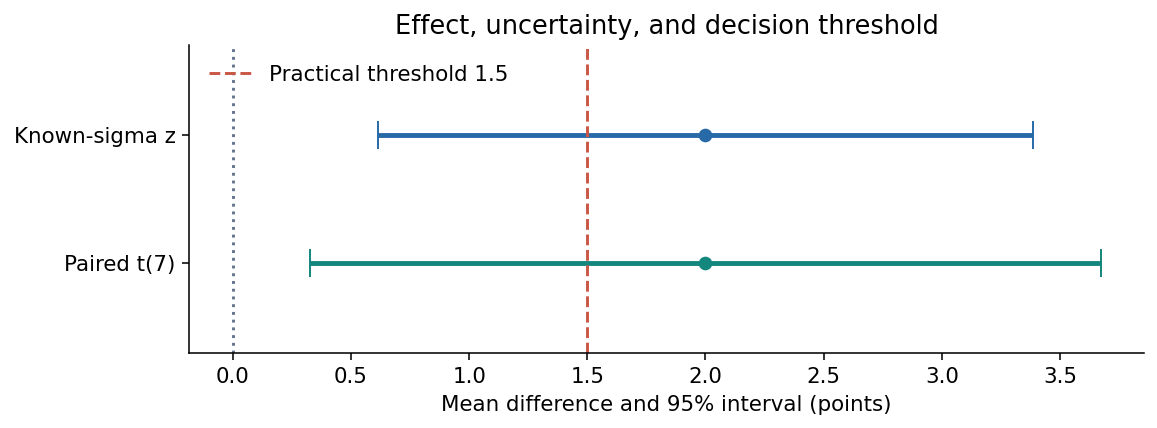

In [4]:
print('Raw effect:',t['mean'],'teaching points; d_z:',t['d_z'])
print('Practical threshold:',spec['practical_threshold'],'inside t CI:',t['interval'][0]<1.5<t['interval'][1])
fig,ax=plt.subplots(figsize=(8.5,3.3))
for y,v,color in [(1,z,'#2869a8'),(0,t,'#13867d')]:
    lo,hi=v['interval'];ax.errorbar(v['mean'],y,xerr=[[v['mean']-lo],[hi-v['mean']]],fmt='o',capsize=7,color=color,lw=2.5)
ax.axvline(0,color='#64748b',ls=':');ax.axvline(1.5,color='#ca5646',ls='--',label='Practical threshold 1.5')
ax.set(yticks=[0,1],yticklabels=['Paired t(7)','Known-sigma z'],xlabel='Mean difference and 95% interval (points)',ylim=(-.7,1.7),title='Effect, uncertainty, and decision threshold')
ax.legend(frameon=False,loc='upper left');show(fig)

### 4. 精确符号翻转
每个位置±一次，共256个标签。零也保留两个标签，重复的总差不能去重后均匀计权。这里先用独立的product/Fraction表达核对，再画频数。

Tail count: 12 label count: 256 exact p: 3/64
All-zero p: 1.0


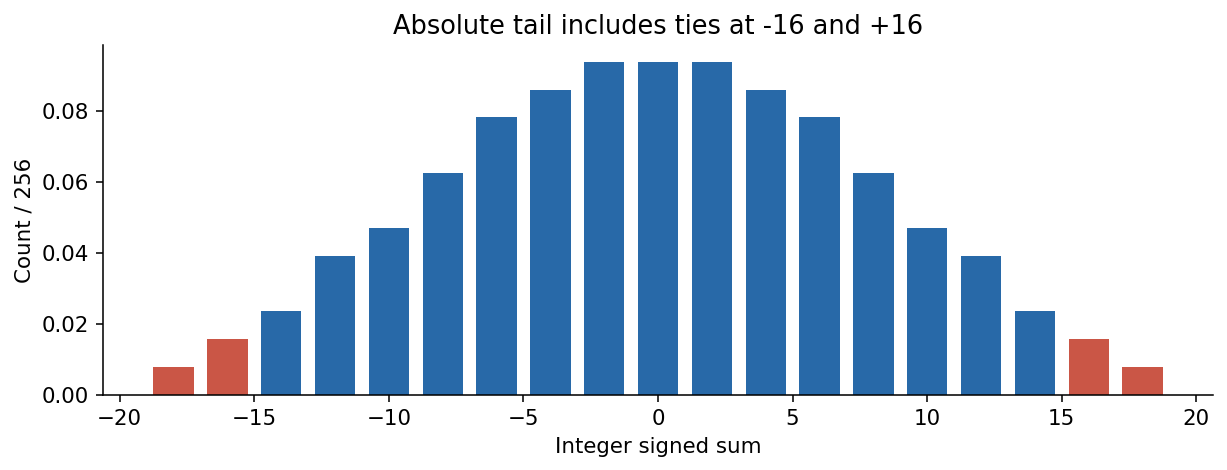

In [5]:
raw_sums=[sum(sign*v for sign,v in zip(signs,map(abs,d))) for signs in product([-1,1],repeat=n)]
tail=sum(abs(value)>=abs(sum(d)) for value in raw_sums)
flip=e.exact_signflip(d)
e.require(len(raw_sums)==256 and tail==12 and Fraction(tail,len(raw_sums))==Fraction(3,64),'exact count mismatch')
e.require(raw_sums==flip['sums'],'all label sums must be retained in order')
print('Tail count:',tail,'label count:',len(raw_sums),'exact p:',Fraction(tail,len(raw_sums)))
print('All-zero p:',e.exact_signflip([0,0,0])['p_two_sided'])
x=np.array([int(v) for v in flip['counts']]);masses=np.array(list(flip['counts'].values()))/256
fig,ax=plt.subplots(figsize=(9,3.6));ax.bar(x,masses,width=1.5,color=['#ca5646' if abs(v)>=16 else '#2869a8' for v in x])
ax.set(xlabel='Integer signed sum',ylabel='Count / 256',title='Absolute tail includes ties at -16 and +16')
show(fig)

### 5. 先验证完整设计，再生成随机数
每种机制用明确seed偏移。功效实验直接抽Z的正确Gaussian分布，节约运行量；不会用模拟重新决定主要检验。输出保留计数、比例、MC标准误和Wilson频率区间。

delta=0.0, n=8: theory=0.050000000; 514/10000, MC_SE=0.002208
delta=0.0, n=32: theory=0.050000000; 510/10000, MC_SE=0.002200
delta=0.0, n=128: theory=0.050000000; 478/10000, MC_SE=0.002133
delta=0.5, n=8: theory=0.108954618; 1087/10000, MC_SE=0.003113
delta=0.5, n=32: theory=0.292988936; 2871/10000, MC_SE=0.004524
delta=0.5, n=128: theory=0.807430419; 8017/10000, MC_SE=0.003987
delta=1.0, n=8: theory=0.292988936; 2999/10000, MC_SE=0.004582
delta=1.0, n=32: theory=0.807430419; 8073/10000, MC_SE=0.003944
delta=1.0, n=128: theory=0.999890872; 9998/10000, MC_SE=0.000141
delta=2.0, n=8: theory=0.807430419; 8108/10000, MC_SE=0.003917
delta=2.0, n=32: theory=0.999890872; 9996/10000, MC_SE=0.000200
delta=2.0, n=128: theory=1.000000000; 10000/10000, MC_SE=0.000000


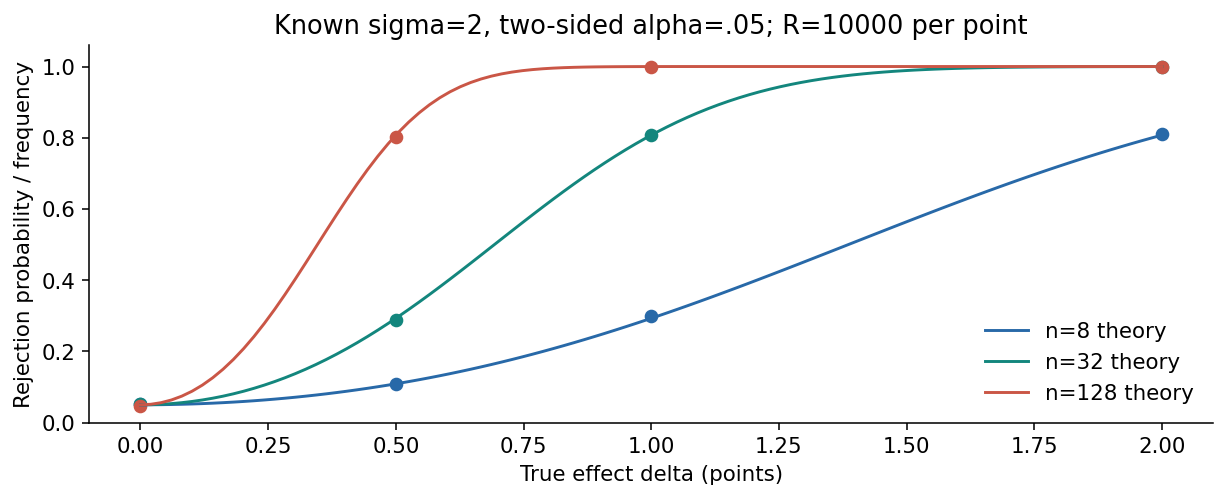

In [6]:
sim=e.simulations(spec)
for entry in sim['power']:
    obs=entry['observed']
    print(f"delta={entry['delta']}, n={entry['n']}: theory={entry['power']:.9f}; {obs['count']}/{obs['repetitions']}, MC_SE={obs['mc_se']:.6f}")
fig,ax=plt.subplots(figsize=(9,3.8))
delta_grid=np.linspace(0,2,100)
for n,color in [(8,'#2869a8'),(32,'#13867d'),(128,'#ca5646')]:
    theory=[e.gaussian_power(float(v),2,n)['power'] for v in delta_grid]
    ax.plot(delta_grid,theory,color=color,label=f'n={n} theory')
    values=[v for v in sim['power'] if v['n']==n]
    ax.scatter([v['delta'] for v in values],[v['observed']['rate'] for v in values],color=color)
ax.set(xlabel='True effect delta (points)',ylabel='Rejection probability / frequency',title='Known sigma=2, two-sided alpha=.05; R=10000 per point',ylim=(0,1.06));ax.legend(frameon=False,loc='lower right')
show(fig)

### 6. 比较家族也需要定义
20个独立真零假设给1−.95²⁰≈.641514；Bonferroni门槛.0025。其并集上界证明不需要独立，但这里的精确理论曲线使用独立模型。有限频率及Wilson区间不是家族率的数学证明。

m= 1 theory= 0.05 0.05
unadjusted: {'count': 501, 'repetitions': 10000, 'rate': 0.0501, 'mc_se': 0.002181513007066426, 'wilson95': [0.04599440546592007, 0.05455111626801472]} Bonferroni: {'count': 501, 'repetitions': 10000, 'rate': 0.0501, 'mc_se': 0.002181513007066426, 'wilson95': [0.04599440546592007, 0.05455111626801472]}
m= 5 theory= 0.2262190625 0.049009950100000005
unadjusted: {'count': 2283, 'repetitions': 10000, 'rate': 0.2283, 'mc_se': 0.004197369533410181, 'wilson95': [0.2201785572310384, 0.23663010748358726]} Bonferroni: {'count': 478, 'repetitions': 10000, 'rate': 0.0478, 'mc_se': 0.0021334282270561626, 'wilson95': [0.043789399861243195, 0.05215788826519671]}
m= 20 theory= 0.6415140775914578 0.04883012474683423
unadjusted: {'count': 6441, 'repetitions': 10000, 'rate': 0.6441, 'mc_se': 0.004787851188163642, 'wilson95': [0.6346622886663074, 0.6534270430032636]} Bonferroni: {'count': 504, 'repetitions': 10000, 'rate': 0.0504, 'mc_se': 0.0021876891918186183, 'wilson95': [0.0462

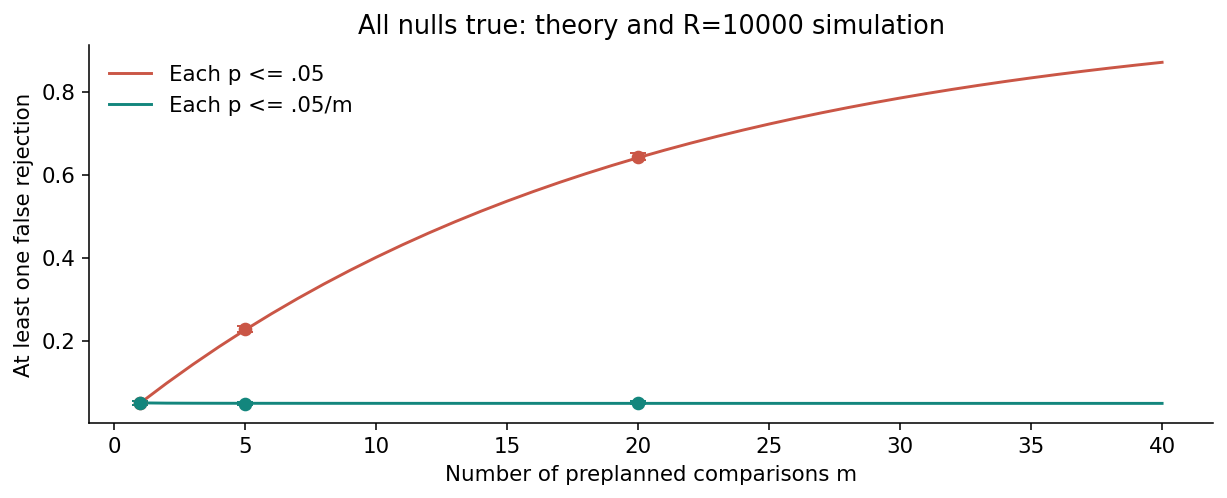

In [7]:
for entry in sim['families']:
    print('m=',entry['m'],'theory=',entry['unadjusted'],entry['bonferroni'])
    print('unadjusted:',entry['observed_unadjusted'],'Bonferroni:',entry['observed_bonferroni'])
fig,ax=plt.subplots(figsize=(9,3.8));grid=range(1,41)
for key,color,obs_key,label in [('unadjusted','#ca5646','observed_unadjusted','Each p <= .05'),('bonferroni','#13867d','observed_bonferroni','Each p <= .05/m')]:
    ax.plot(list(grid),[e.family_error(m)[key] for m in grid],color=color,label=label)
    for entry in sim['families']:
        o=entry[obs_key];lo,hi=o['wilson95'];ax.errorbar(entry['m'],o['rate'],yerr=[[o['rate']-lo],[hi-o['rate']]],fmt='o',color=color,capsize=4)
ax.set(xlabel='Number of preplanned comparisons m',ylabel='At least one false rejection',title='All nulls true: theory and R=10000 simulation');ax.legend(frameon=False);show(fig)

### 7. 中途查看改变拒绝事件
这些时点共享数据，相关而不独立。任一次过线可以包括最后已经回到门槛内的路径。另一个独立模拟展示事后选单侧方向的.10理论错误率。

Final only: {'count': 514, 'repetitions': 10000, 'rate': 0.0514, 'mc_se': 0.002208122279222779, 'wilson95': [0.04724182497055032, 0.05590269836762071]}
Any of 8 looks: {'count': 1742, 'repetitions': 10000, 'rate': 0.1742, 'mc_se': 0.0037928137312554645, 'wilson95': [0.16689170290417463, 0.18175851043415822]}
Posthoc direction: {'seed_offset': 2100, 'theory': 0.1, 'observed': {'count': 1012, 'repetitions': 10000, 'rate': 0.1012, 'mc_se': 0.0030159336862736223, 'wilson95': [0.09544116846787132, 0.10726510863258032]}}


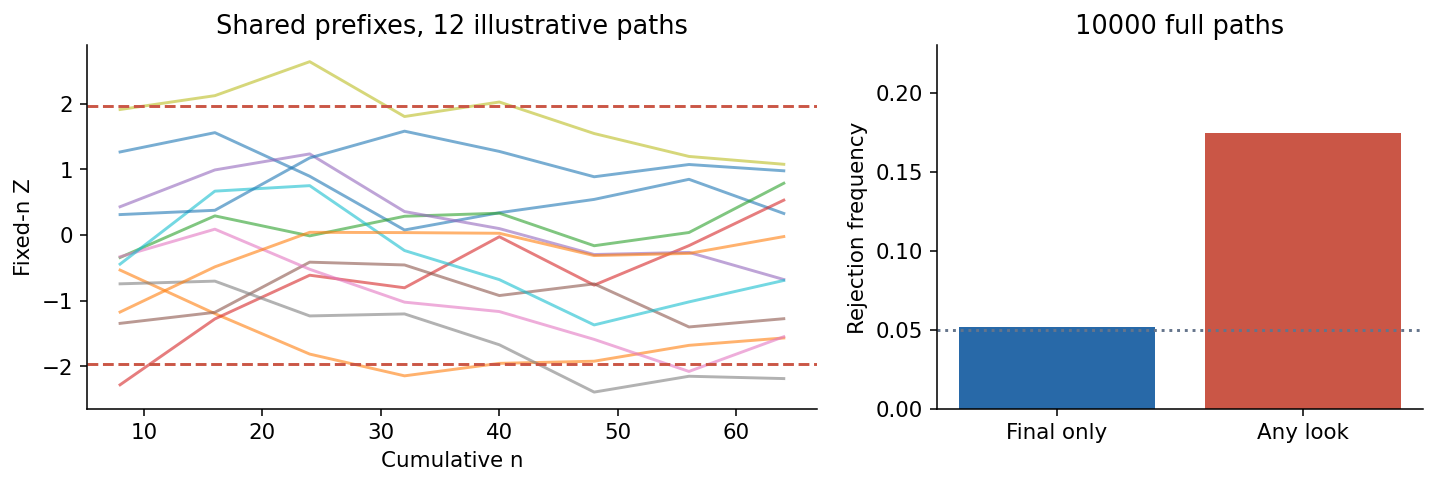

In [8]:
optional=sim['optional_looks']
print('Final only:',optional['final_only'])
print('Any of 8 looks:',optional['any_look'])
print('Posthoc direction:',sim['posthoc_direction'])
fig,axes=plt.subplots(1,2,figsize=(10.5,3.7),gridspec_kw={'width_ratios':[1.5,1]})
for path in optional['first_12_standardized_paths']:axes[0].plot(optional['looks'],path,alpha=.6)
for value in [-optional['critical'],optional['critical']]:axes[0].axhline(value,color='#ca5646',ls='--')
axes[0].set(xlabel='Cumulative n',ylabel='Fixed-n Z',title='Shared prefixes, 12 illustrative paths')
obs=[optional['final_only'],optional['any_look']]
axes[1].bar([0,1],[v['rate'] for v in obs],color=['#2869a8','#ca5646'])
axes[1].axhline(.05,color='#64748b',ls=':');axes[1].set(xticks=[0,1],xticklabels=['Final only','Any look'],ylim=(0,.23),ylabel='Rejection frequency',title='10000 full paths')
show(fig)

### 8. 模拟误差不等于原实验的不确定性
R增加改善对程序概率的数值近似，不增加原始8对数据的信息。插件MC标准误在全命中时为0，Wilson区间仍有宽度。极高功效浮点显示1时，type_II单独保留正数，避免错认数学漏检率为0。

Rounded power: 1.0 separately retained type-II probability: 4.22992153313186e-21
10000/10000: {'count': 10000, 'repetitions': 10000, 'rate': 1.0, 'mc_se': 0.0, 'wilson95': [0.9996160016293234, 1.0]}


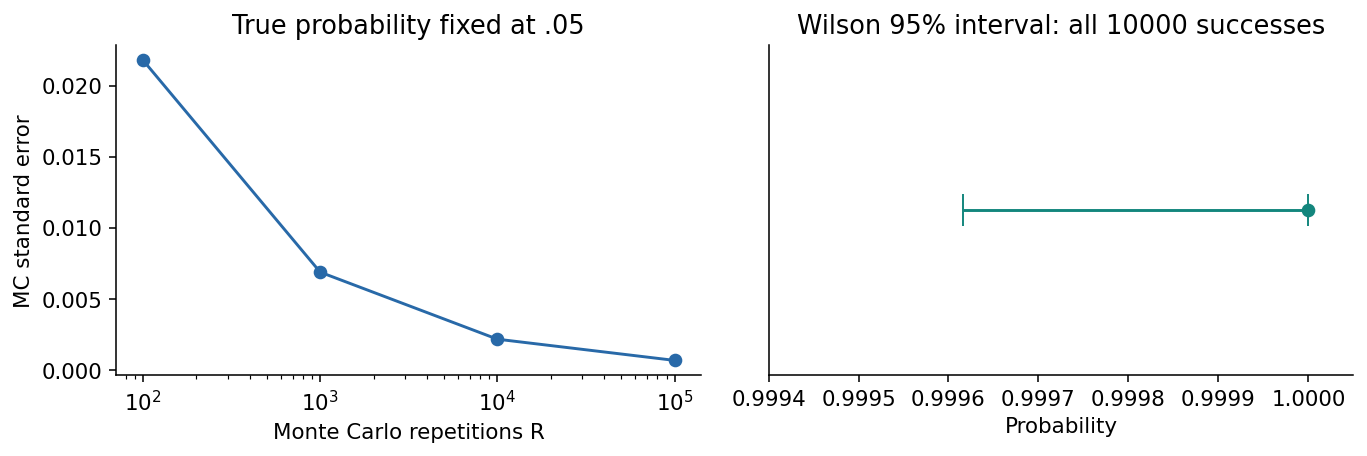

In [9]:
high=e.gaussian_power(2,2,128)
print('Rounded power:',high['power'],'separately retained type-II probability:',high['type_II'])
all_hit=e.binomial_summary(10000,10000)
print('10000/10000:',all_hit)
fig,axes=plt.subplots(1,2,figsize=(10,3.5));rgrid=np.array([100,1000,10000,100000])
axes[0].plot(rgrid,np.sqrt(.05*.95/rgrid),marker='o',color='#2869a8');axes[0].set_xscale('log')
axes[0].set(xlabel='Monte Carlo repetitions R',ylabel='MC standard error',title='True probability fixed at .05')
lo,hi=all_hit['wilson95'];axes[1].errorbar(1,0,xerr=[[1-lo],[hi-1]],fmt='o',capsize=8,color='#13867d')
axes[1].set(xlabel='Probability',yticks=[],xlim=(.9994,1.00005),ylim=(-.5,.5),title='Wilson 95% interval: all 10000 successes')
axes[1].ticklabel_format(useOffset=False,axis='x');show(fig)

## Checks
显式require不会被python -O移除。先验验证必须覆盖末项、完整常量和不支持的数值类型。以下故意失败只捕获预期ValueError，没有隐藏其他异常。

In [10]:
checks=e.self_test()
print('Core checks:',checks)
for value in ([1,1,float('nan')], [1,True], [1,'2'], [1,Fraction(1,2)], np.array([1,2],dtype=object)):
    try:
        e.moments(value)
    except ValueError as error:
        print('Expected rejection:',str(error))
    else:
        raise RuntimeError('Invalid input was accepted')
print('Compensated mean:',e.moments([-1,1,1e-100])['mean'])
print('Constant t result:',e.paired_t_test([2,2,2]))
print('Constant known-sigma result:',e.known_sigma_test([2,2,2],2)['status'])
e.require(e.exact_signflip([0,0])['p_two_sided']==1,'true-zero sign flip must be valid')
e.require(e.moments([-1,1,1e-100])['mean']==1e-100/3,'mixed-scale residual lost')

Core checks: {'passed': 15}
Expected rejection: values[2] is nonfinite or outside the supported range
Expected rejection: values[1] requires a supported real scalar
Expected rejection: values[1] requires a supported real scalar
Expected rejection: values[1] requires a supported real scalar
Expected rejection: values rejects object/bool/complex/extended arrays
Compensated mean: 3.3333333333333336e-101
Constant t result: {'status': 'degenerate_zero_sample_sd', 'method': 'paired_Gaussian_t', 'n': 3, 'mean': 2.0, 'sd': 0.0, 'null': 0.0, 'alpha': 0.05, 'statistic': None, 'p_two_sided': None, 'interval': None, 'reject': None, 'd_z': None}
Constant known-sigma result: ok


## Next Steps
写一份完整报告：配对单位、原始效应2分、d_z=1、未知σ下的主要t区间与p、实用阈值1.5和比较历史。解释为什么这里不按三种p值中最小者选择结论；为什么不显著不等于等效，显著也不证明因果。

扩展前先冻结新的问题与模型，再复制配置。详见README的范围限制：只支持受限float64教学域，拒绝扩展精度/任意对象/非整数符号翻转，不提供任意尾部或任意操作系统的精度保证。已验证顺序InProcessKernel执行；Anaconda安装、浏览器Jupyter UI、socket传输和跨版本随机流逐比特一致性仍未测试。